In [143]:
# les bibliothèques utilise
import pandas as pd
import matplotlib.pyplot as plt

### 1. Chargement des données
On charge le fichier CSV fourni par Sell4All puis on affiche les 5 premières
lignes pour se faire une première idée du contenu.

In [144]:
Data="data\dataset-sell4all.csv"
df=pd.read_csv(Data)

In [145]:
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


Les 5 premières lignes montrent que chaque ligne correspond à un client, avec
des informations personnelles (nom, téléphone, email, adresse, code postal), sa
localisation (`Country`), sa date/heure de dernière connexion, ainsi que trois
variables démographiques et commerciales : `Age`, `Gender` et
`Customer spendings` (le montant dépensé sur le site).

### 2. Structure du dataset
On regarde maintenant la taille du dataset, le nom des colonnes et le type de
données de chacune.

In [146]:
nb_lignes, nb_colonnes = df.shape
print("Nombre de lignes (observations) : "  , nb_lignes)
print("Nombre de colonnes (variables)   : " , nb_colonnes)

Nombre de lignes (observations) :  505
Nombre de colonnes (variables)   :  11


In [147]:
df.describe()

,Age,Customer spendings
count,505.000000,505.000000
mean,46.083168,311.168317
std,16.193553,169.873545
min,18.000000,3.000000
25%,33.000000,165.000000
50%,46.000000,307.000000
75%,60.000000,464.000000
max,74.000000,598.000000


In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Name                     505 non-null    str  
 1   Phone Number             505 non-null    str  
 2   Email                    505 non-null    str  
 3   Address                  505 non-null    str  
 4   Country                  505 non-null    str  
 5   Postal code              505 non-null    str  
 6   Last date of connection  505 non-null    str  
 7   Last time of connection  505 non-null    str  
 8   Age                      505 non-null    int64
 9   Gender                   505 non-null    str  
 10  Customer spendings       505 non-null    int64
dtypes: int64(2), str(9)
memory usage: 43.5 KB


In [149]:
print(df.dtypes)

Name                         str
Phone Number                 str
Email                        str
Address                      str
Country                      str
Postal code                  str
Last date of connection      str
Last time of connection      str
Age                        int64
Gender                       str
Customer spendings         int64
dtype: object


**Comment lire ce résumé technique ?**

- **Nombre d'entrées** : `df.info()` indique `505 entries`, ce qui correspond au nombre de clients enregistrés dans le fichier csv.
- 
- **« Non-null » (non nul)** : pour chaque colonne, `505 non-null` signifie qu'il
  n'y a **aucune valeur manquante** sur cette colonne  , les 505 lignes ont bien
  une valeur renseignée. Si une colonne affichait par exemple `480 non-null`, cela
  voudrait dire que 25 valeurs sont manquantes sur cette colonne.
  
- **Types de données** : on trouve deux types principaux :
  - `str` (texte) pour les colonnes comme `Name`, `Country`, `Gender`,
    `Email`, `Address`, `Postal code` et les dates de connexion ;
  - `int64` (nombre entier) pour `Age` et `Customer spendings`, ce qui est
    cohérent puisqu'un âge et un montant dépensé sont des nombres.

Ce résumé nous permet déjà de savoir que le dataset ne contient, a priori, aucune
valeur manquante et que les deux colonnes numériques qui nous intéressent le plus
(`Age` et `Customer spendings`) ont bien un type numérique.


### 3. Audit de qualité des données

Avant toute analyse ou tout nettoyage, on vérifie la qualité du dataset selon 5
dimensions : **complétude (deja traite), validité, exactitude, cohérence et unicité**.


 3.1 **Validité**

In [150]:
T_Age=df['Age'].dtype
print("Type de 'Age' :", T_Age)

T_Customer_spending= df['Customer spendings'].dtype
print("Type de 'Customer spendings' :", T_Customer_spending)
print()
print(f"Etendue de l'âge :{df['Age'].min()} à { df['Age'].max()} ans ")
print(f"Etendue des dépenses :{ df['Customer spendings'].min()}€ à { df['Customer spendings'].max()}€")

Type de 'Age' : int64
Type de 'Customer spendings' : int64

Etendue de l'âge :18 à 74 ans 
Etendue des dépenses :3€ à 598€


**Constat :** `Age` et `Customer spendings` sont bien de type numérique
(`int64`), ce qui permet de faire des calculs statistiques directement. Les âges
vont de 18 à 74 ans : c'est une plage réaliste pour une clientèle adulte. Les
dépenses vont de 3 € à 598 €, sans valeur négative ni valeur nulle : ce sont des
montants plausibles pour un site de vente de vêtements d'occasion. On ne détecte
donc aucune valeur impossible sur ces deux colonnes.

3.2 **Exactitude** : est ce que t'il  des valeurs extrêmes ou suspectes ?

In [151]:
df[['Age', 'Customer spendings']].describe()

,Age,Customer spendings
count,505.000000,505.000000
mean,46.083168,311.168317
std,16.193553,169.873545
min,18.000000,3.000000
25%,33.000000,165.000000
50%,46.000000,307.000000
75%,60.000000,464.000000
max,74.000000,598.000000


In [152]:
Age_et_Customer_spendings=df[['Age' , 'Customer spendings']]
Age_et_Customer_spendings

,Age,Customer spendings
0,71,356
1,37,173
2,24,105
3,37,28
4,42,13
...,...,...
500,28,182
501,46,25
502,43,42
503,20,511


In [153]:
for colonne in Age_et_Customer_spendings :
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)
    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    outliers_iqr = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]

    print(f"{colonne}: Q1={q1}, Q3={q3}, IQR={iqr} \n")
    
    print(f"  Bornes = [{borne_basse} ; {borne_haute}] ")
    print(f"  Outliers statistiques : {len(outliers_iqr)} \n")

Age: Q1=33.0, Q3=60.0, IQR=27.0 

  Bornes = [-7.5 ; 100.5] 
  Outliers statistiques : 0 

Customer spendings: Q1=165.0, Q3=464.0, IQR=299.0 

  Bornes = [-283.5 ; 912.5] 
  Outliers statistiques : 0 



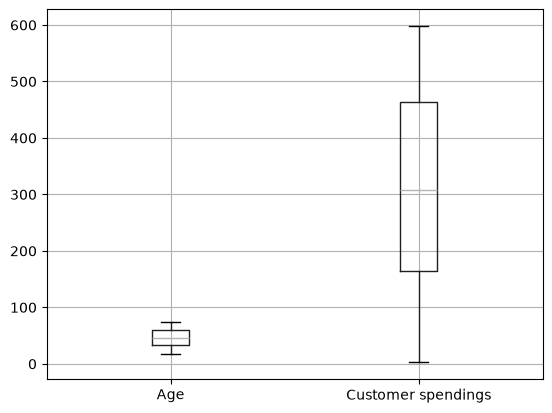

In [154]:
df.boxplot(column=['Age', 'Customer spendings'])
plt.show()

**Constat :** la méthode de l'IQR (écart interquartile) ne détecte **aucune
valeur aberrante** sur `Age` ni sur `Customer spendings` : toutes les valeurs se
situent dans un intervalle statistiquement normal. On ne supprime donc aucun
outlier, puisqu'il n'y en a pas .

3.3 **Cohérence** : les catégories sont elles écrites de facon uniforme ?

In [155]:
Valu_Gender=df['Gender'].unique()
print("Valeurs uniques de 'Gender' :",Valu_Gender)
print()

Valu_payes=df['Country'].unique()
print("Nombre de pays differents :", len(Valu_payes))
print()

print("Valeurs uniques de 'Country' :")
print(sorted(Valu_payes))

Valeurs uniques de 'Gender' : <StringArray>
['Man', 'Women']
Length: 2, dtype: str

Nombre de pays differents : 35

Valeurs uniques de 'Country' :
['Australia', 'Austria', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'France', 'Germany', 'India', 'Indonesia', 'Ireland', 'Italy', 'Mexico', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Russian Federation', 'Singapore', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Turkey', 'Ukraine', 'United Kingdom', 'United States', 'Vietnam']


**Constat :** 
- la colonne `Gender` ne contient que deux valeurs (`Man` et
`Women`),On note que on a  une asymétrie
grammaticale (`Man` au singulier, `Women` au pluriel), donc on peut le changer. 

- La colonne `Country` contient 35 pays, tous écrits de façon
homogène (une seule orthographe par pays, pas de doublons du  type France /
france). Aucune fusion de catégories n'est donc nécessaire ici.


- les colonnes `Last date of connection` et `Last time of connection` étaient stockées en **string** avec deux formats de date mélangés (`5-Apr-21` et
`oct. 29, 2021`), nous les avons converties en datetime et timedelta pour garantir la cohérence des types.  meme si  cette colonne ne fait pas partie des données à livrer
(`Country`, `Age`, `Gender`, `Customer spendings`).

 - Convertir l'heure de connexion

In [156]:

df['Last time of connection'] = pd.to_datetime( df['Last time of connection'], format='%H:%M').dt.time

In [157]:
print("Heure de connexion après conversion :")
T_Ltc=df['Last time of connection'].dtype
print(f"Type : {T_Ltc}")

Heure de connexion après conversion :
Type : object


In [158]:
print(df['Last time of connection'].head(7))

0    04:39:00
1    00:36:00
2    03:37:00
3    02:34:00
4    06:28:00
5    10:38:00
6    06:55:00
Name: Last time of connection, dtype: object


- Convertir la date en datetime

In [159]:
df['Last date of connection']=pd.to_datetime(df['Last date of connection'],  format='mixed',  dayfirst=True)

In [160]:
print("la date apres conversion")
T_Ldc=df['Last date of connection'].dtype
print(f"type{T_Ldc}")

la date apres conversion
typedatetime64[us]


In [161]:
df['Last date of connection'].head(7)

0   2021-04-05
1   2021-10-10
2   2022-07-02
3   2022-02-19
4   2022-03-31
5   2021-01-25
6   2021-05-29
Name: Last date of connection, dtype: datetime64[us]

In [162]:
print("\n Vérification des types ")
print(df[['Last date of connection', 'Last time of connection']].dtypes)


 Vérification des types 
Last date of connection    datetime64[us]
Last time of connection            object
dtype: object


In [163]:
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,2021-04-05,04:39:00,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,2021-10-10,00:36:00,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2022-07-02,03:37:00,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,2022-02-19,02:34:00,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,2022-03-31,06:28:00,42,Women,13


### 4. Analyse exploratoire ET les statistiques demandées

In [164]:
# la médiane et la moyenne  de  colonne 'Age'
Mean_Age=df['Age'].mean()
print( "la moyenne est : " , Mean_Age)

Mediane_Age=df['Age'].median()
print("la mediane est : " , Mediane_Age)

la moyenne est :  46.08316831683168
la mediane est :  46.0


**interprétation des résultats de la colonne `Age` :** la moyenne et la médiane de l'âge sont très proches
(autour de 46 ans), ce qui indique une distribution assez symétrique et aussi confirme l'absence d'outliers détectée à l'étape précédente.

In [165]:
# la médiane et la moyenne  de  colonne 'Customer spendings '
Mean_Customer_spendings =df['Customer spendings'].mean()
print( "la moyenne est : " , Mean_Customer_spendings)

Mediane_Customer_spendings =df['Customer spendings'].median()
print("la mediane est : " , Mediane_Customer_spendings)

la moyenne est :  311.16831683168317
la mediane est :  307.0


##### médiane d'âge par pays

In [166]:
median_age_payes = df.groupby('Country')['Age'].median().sort_values(ascending=False)

print(median_age_payes)

Country
Turkey                60.0
France                56.5
Spain                 54.5
Norway                54.0
Germany               53.0
Philippines           51.0
Brazil                49.5
South Korea           49.5
Poland                49.5
Ireland               49.0
United States         48.5
United Kingdom        48.5
Netherlands           48.0
Vietnam               48.0
Costa Rica            48.0
Russian Federation    48.0
Mexico                47.0
Ukraine               46.0
Canada                46.0
Chile                 46.0
India                 45.5
Australia             44.0
Pakistan              44.0
South Africa          43.0
Austria               43.0
Singapore             41.5
Indonesia             41.5
Italy                 41.0
Sweden                40.0
Belgium               39.0
New Zealand           38.0
Peru                  38.0
Nigeria               37.0
China                 35.0
Colombia              29.0
Name: Age, dtype: float64


#### Visualisation  , dépenses des clients par pays

On représente la dépense moyenne des clients pour chaque pays sous forme d'un
graphique à barres. 

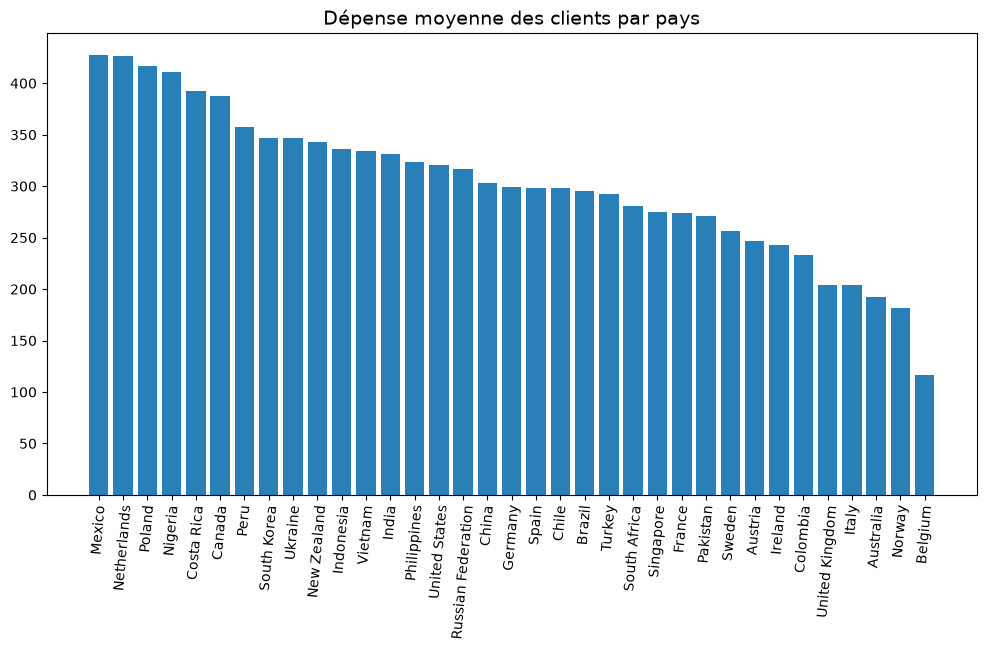

In [167]:
depense=df.groupby('Country')['Customer spendings'].median().sort_values(ascending=False)

pays_depense=depense.index
custmer_depense=depense.values

plt.figure(figsize=(12, 6))
plt.bar(pays_depense , custmer_depense  , color='#2980B9')
plt.xticks(rotation=85)
plt.title("Dépense moyenne des clients par pays", fontsize=14)
plt.show()

### 5. Nettoyage des données

- Suppression des clients ayant dépensé moins de 10 €

In [168]:
nb_avant=df.shape[0]

clients_sous_10=df[df['Customer spendings']<10]

print("le nombre des cliens  ayant dépensé moins de 10 € est : " , clients_sous_10.shape[0])
clients_sous_10[['Name' , 'Country', 'Customer spendings']]

le nombre des cliens  ayant dépensé moins de 10 € est :  3


,Name,Country,Customer spendings
132,Lara Hubbard,Pakistan,7
148,Rae Lynch,India,9
482,Valentine Richardson,United States,3


In [169]:
df_copy = df.copy()
df_clean = df_copy[df_copy['Customer spendings'] >= 10]

nb_apres = df_clean.shape[0]
print(f"Lignes avant suppression : {nb_avant}")
print(f"Lignes après suppression : {nb_apres}")
print(f"Lignes supprimées        : {nb_avant - nb_apres}")

Lignes avant suppression : 505
Lignes après suppression : 502
Lignes supprimées        : 3


- Suppression des doublons

In [170]:
nb_avant_doublons = df_clean.shape[0]
nb_doublons_restants = df_clean.duplicated().sum()

print(f"Lignes avant suppression des doublons : {nb_avant_doublons}")
print(f"Doublons détectés a ce stade           : {nb_doublons_restants}")

Lignes avant suppression des doublons : 502
Doublons détectés a ce stade           : 5


In [171]:
df_clean = df_clean.drop_duplicates()

nb_apres_doublons = df_clean.shape[0]
print(f"Lignes apres suppression des doublons : {nb_apres_doublons}")
print(f"Lignes supprimées                     : {nb_avant_doublons - nb_apres_doublons}")

Lignes apres suppression des doublons : 497
Lignes supprimées                     : 5


### 5. Validation 

In [172]:
rapport_qualite = pd.DataFrame({
    
    'Avant nettoyage': [
        df.shape[0],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
    ],
    
    'Après nettoyage': [
        df_clean.shape[0],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum(),
    ]
}, index=['Nombre de lignes', 'Valeurs manquantes', 'Doublons'])

rapport_qualite

,Avant nettoyage,Après nettoyage
Nombre de lignes,505,497
Valeurs manquantes,0,0
Doublons,5,0


### 6.Export du fichier CSV final

In [173]:
colonnes_finales = ['Country', 'Age', 'Gender', 'Customer spendings']

In [174]:
df_clean_copy=df_clean[colonnes_finales].copy()

In [175]:
df_final=df_clean_copy

In [176]:
df_final['Gender'] = df_final['Gender'].replace({'Women': 'Woman'})

In [177]:
df_final.head()

,Country,Age,Gender,Customer spendings
0,Norway,71,Man,356
1,Pakistan,37,Woman,173
2,Colombia,24,Woman,105
3,South Africa,37,Woman,28
4,France,42,Woman,13


In [178]:
df_final = df_final.sort_values(by=['Country', 'Customer spendings'], ascending=[True, False])

In [179]:
df_final

,Country,Age,Gender,Customer spendings
268,Australia,38,Man,559
251,Australia,66,Woman,555
386,Australia,44,Woman,506
231,Australia,55,Man,437
165,Australia,57,Woman,328
...,...,...,...,...
197,Vietnam,39,Woman,261
157,Vietnam,48,Man,226
258,Vietnam,56,Woman,128
202,Vietnam,48,Man,61


In [180]:
df_final.to_csv('dataset-sell4all-clean.csv', index=False)

**Vérification**

In [181]:
verification = pd.read_csv('dataset-sell4all-clean.csv')
print("Shape du fichier relu :", verification.shape)
print("Valeurs manquantes    :", verification.isnull().sum().sum())
print("Doublons              :", verification.duplicated().sum())
verification.head()

Shape du fichier relu : (497, 4)
Valeurs manquantes    : 0
Doublons              : 0


,Country,Age,Gender,Customer spendings
0,Australia,38,Man,559
1,Australia,66,Woman,555
2,Australia,44,Woman,506
3,Australia,55,Man,437
4,Australia,57,Woman,328


## 7. Conclusion

Le dataset `dataset-sell4all.csv` s'est révélé globalement de bonne qualité :
aucune valeur manquante, des types de données cohérents, des valeurs réalistes
et des catégories homogènes. Après nettoyage, le fichier
`dataset-sell4all-clean.csv` contient des données fiables, prêtes à servir de
base pour un futur système de recommandation basé sur l'intelligence
artificielle.
